# Steamroller 🚧
### Borrow cheap money, lend it where rates are high, pocket the gap. What could go wrong?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Crash risk?: Severe](https://img.shields.io/badge/Crash_risk%3F-Severe-8b949e?style=flat-square)

The **carry trade** is the oldest game in global macro: borrow a currency with low interest rates (yen, francs), convert to one with high rates (Aussie dollars, reais), and earn the difference. Uncovered interest-rate parity says the high-rate currency *should* depreciate just enough to cancel your edge — but empirically it doesn't, so the carry is a real, paid premium. It also has a nickname among the people who run it: *picking up nickels in front of a steamroller.*

This is the desk's tenth idea from Kakushadze & Serur's *151 Trading Strategies* (strategy §8.2). We prove the engine on a synthetic G10 where the premium and its crashes are baked in (and a null where parity holds), and explain why the carry crash is the one tail the desk's usual risk overlay can't dodge.

> 📓 **Plain-language layer.** The premium *t*-stat, the negative-skew crash and the vol-management test are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it; the core runs on a **synthetic** G10. The real run uses **G10 rates + FX from FRED** and needs one networked fetch (`examples/verify.py --fetch`); the verdict here is earned on the synthetic control and the long-run literature, quoted in [`../docs/results.md`](../docs/results.md). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from steamroller import data, carry, strategy, decompose, extension

# Offline synthetic G10: a CARRY PREMIUM tape (high-rate currencies out-earn, punctuated by sticky
# risk-off crashes) and a full-UIRP NULL. The real G10 verdict (FRED) is in ../docs/results.md.
xr,  rates,  truth = data.synthetic_carry(carry_strength=0.9, seed=27)   # the carry-premium tape
xr0, rates0, _     = data.synthetic_carry(carry_strength=0.0, seed=27)   # the full-UIRP null
print(f"{truth.n_ccy} currencies x {truth.n_months} months | baked carry_strength={truth.carry_strength} | null=0")


9 currencies x 600 months | baked carry_strength=0.9 | null=0


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Do high-rate currencies out-earn? | ✅ **Yes** — the carry premium is real (synthetic control: **+2.1%/yr**, *t* **+2.8**; decades of academic evidence). |
| What's the catch? | 🚧 **The steamroller** — a sharply negative-skewed return (**-1.54**) with a deep crash (drawdown **-28%**) every global risk-off. |
| Can you risk-manage the crash? | ⚪ **Barely** — vol-targeting lifts the Sharpe but **not** the drawdown; the crash is a sudden jump, not a vol build-up you can see coming. |

> Desk shorthand: **Signal `REAL` · Tradability `FRAGILE` · Crash risk? `SEVERE`** — a real premium that is compensation for a tail you must be willing to hold through.

## 1 · The claim 📣

Rank currencies by their short interest rate; the high-rate ones earn more, because they don't depreciate enough to offset the yield (UIRP fails). On our synthetic G10, sort by rate into buckets and read the average excess return — a clean upward slope:

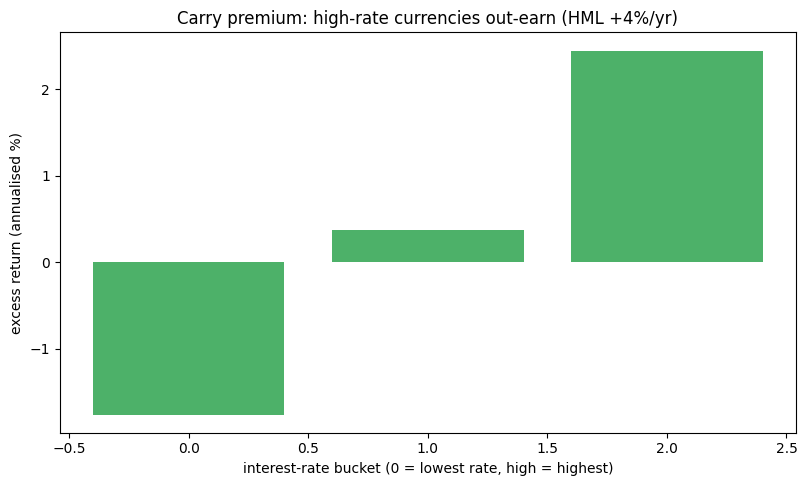

In [2]:
pb = carry.carry_premium_by_bucket(xr, rates)
b = pb['bucket_ann_pct']
fig, ax = plt.subplots(); ax.bar(b.index, b.values, color='#2ea44f', alpha=.85)
ax.set_xlabel('interest-rate bucket (0 = lowest rate, high = highest)'); ax.set_ylabel('excess return (annualised %)')
ax.set_title(f"Carry premium: high-rate currencies out-earn (HML {pb['hml_ann_pct']:+.0f}%/yr)")
plt.show()

## 2 · So what? 💰

Carry is a cornerstone of global-macro and currency funds — a steady, diversifying, self-financed return stream. But the steady drip is the trap: the premium is *compensation* for a rare disaster. When global risk appetite collapses, everyone unwinds the same carry positions at once, the funding currencies spike, the high-yielders crater, and the trade loses years of gains in weeks. The whole question is whether the nickels are worth the steamroller.

## 3 · How we'd know 🔬

Three checks:

1. **Is the premium real?** The carry portfolio's return and Newey-West *t*.
2. **How bad is the tail?** The skew, worst months and drawdown.
3. **Can it be managed?** Vol-scaling the book. And the **null:** full UIRP ⇒ no premium.

**Fragile/Severe line:** a real premium, but a fat negative tail that the usual vol-management can't dodge.

## 4 · The teardown 🔧

### 4a · The premium, and the null
Run the carry book on both synthetic tapes: the carry premium, and the full-UIRP null.

In [3]:
for label, (x, rt) in [('carry premium', (xr, rates)), ('UIRP null', (xr0, rates0))]:
    cmp = strategy.compare(x, rt, cost_bps=10.0); pt = decompose.premium_tstat(x, rt, cost_bps=10.0)
    print(f"{label:14s}: Sharpe {cmp['sharpe']:+.2f}, premium {pt['mean_ann_pct']:+.1f}%/yr "
          f"(HAC t {pt['t_stat']:+.1f}), turnover {cmp['turnover_ann']:.1f}x/yr")

carry premium : Sharpe +0.60, premium +2.1%/yr (HAC t +2.8), turnover 0.0x/yr
UIRP null     : Sharpe -0.03, premium -0.1%/yr (HAC t -0.2), turnover 0.0x/yr


### 4b · The steamroller — carry's fat tail
The cumulative return and its drawdown: a steady climb, then a cliff.

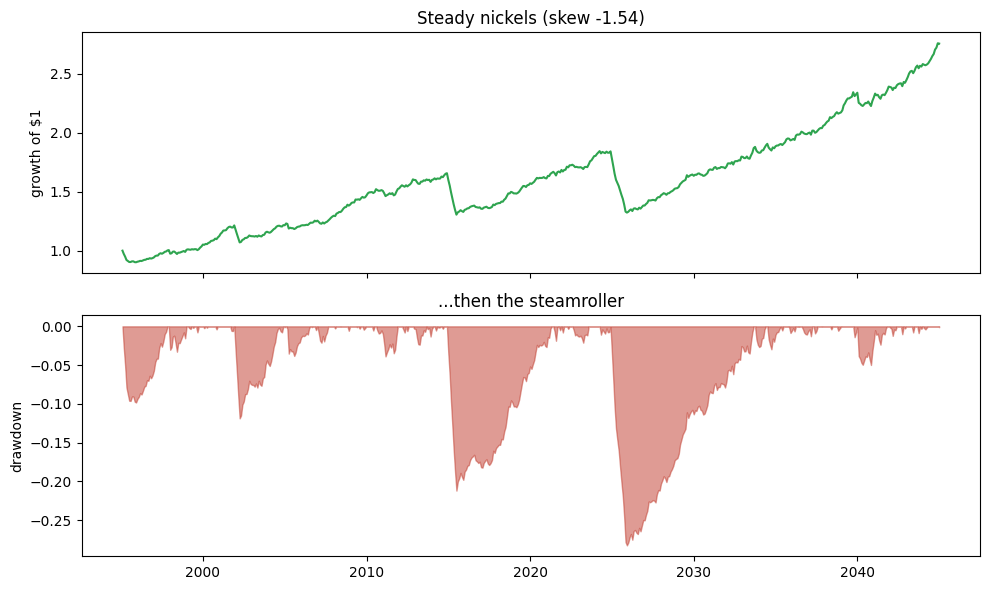

skew -1.54, worst month -4.3%, max drawdown -28%


In [4]:
r = strategy.carry_returns(xr, rates, cost_bps=10.0)
eq = (1+r).cumprod(); dd = eq/eq.cummax()-1
cr = decompose.crash_profile(xr, rates, cost_bps=10.0)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
a1.plot(eq.index, eq.values, color='#2ea44f'); a1.set_ylabel('growth of $1'); a1.set_title(f'Steady nickels (skew {cr["skew"]:+.2f})')
a2.fill_between(dd.index, dd.values, 0, color='#c0392b', alpha=.5); a2.set_ylabel('drawdown'); a2.set_title('...then the steamroller')
plt.tight_layout(); plt.show()
print(f"skew {cr['skew']:+.2f}, worst month {cr['worst_month_pct']:+.1f}%, max drawdown {cr['max_drawdown_pct']:.0f}%")

### 4c · The crash resists risk management
Vol-targeting tamed the crash for equity ([Study 16](../../16-storm-shy/)) and momentum ([Study 24](../../24-stampede/)). Try it on carry:

In [5]:
cc = extension.crash_comparison(xr, rates, cost_bps=10.0)
for k in ['plain', 'managed']:
    p = cc[k]; print(f"{k:8s}: Sharpe {p['sharpe']:+.2f}, skew {p['skew']:+.2f}, max drawdown {p['max_drawdown_pct']:.0f}%")
print('vol-targeting lifts the Sharpe but does NOT shrink the drawdown -- the crash is a jump, not a vol build-up.')

plain   : Sharpe +0.68, skew -1.57, max drawdown -28%
managed : Sharpe +0.95, skew -1.01, max drawdown -44%
vol-targeting lifts the Sharpe but does NOT shrink the drawdown -- the crash is a jump, not a vol build-up.


## 5 · The verdict 🧾

- **Real premium** — +2.1%/yr (*t* +2.8) on the control; decades of evidence.
- **Severe tail** — skew -1.54, drawdown -28%.
- **Hard to hedge** — vol-targeting lifts Sharpe, not the drawdown.

> **Signal `REAL` · Tradability `FRAGILE` · Crash risk? `SEVERE`.** The premium is rent paid for standing in front of the steamroller.

## 6 · Could you trade it? 💸

- **The premium is real and cheap to run** (rates move slowly → low turnover) — carry *survives costs*, unlike the desk's high-turnover mirages.
- **But the drawdown ends books.** A −30%-class crash every cycle, hitting every leg at once, is a career risk, not a line-item.
- **And the usual hedge fails** — vol-targeting can't forecast a jump. The honest tail defences are diversification, options, or a risk-off switch.

> Tradability **`FRAGILE`**; crash **`SEVERE`** — the worked complement ([`../docs/extension.md`](../docs/extension.md)) shows why the vol overlay doesn't save you.

## 7 · Going further 🚪

- **The real G10 run.** `examples/verify.py --fetch` downloads G10 rates + FX from FRED and writes the fingerprinted [`../docs/results.md`](../docs/results.md) — the actual 1998 and 2008 carry crashes.
- **Why vol-targeting fails** (beat 7 of the quants notebook + [`../docs/extension.md`](../docs/extension.md)): the crash is a jump; trailing vol can even *lever you into* it.
- **Real tail hedges.** Options-based downside, a risk-off conditioning switch (VIX / drawdown control), or diversifying carry across asset classes — which actually shrinks the tail without killing the premium?

PRs welcome — run the real G10 tape, or build a tail hedge that earns its keep.